In [47]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from src.load_data import *
from src.preprocess import *

In [2]:
filepath = "data/GlobalWeatherRepository.csv"
df = load_raw_data(filepath)

df = standardize_columns(df)

df = parse_datetime_local(df)

df = parse_datetime_unix(df)

df = drop_duplicates(df)

df_original = df.copy()

In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_pm2.5,air_quality_pm10,air_quality_us_epa_index,air_quality_gb_defra_index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 08:45:00+00:00,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 08:45:00+00:00,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 08:45:00+00:00,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 08:45:00+00:00,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 08:45:00+00:00,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


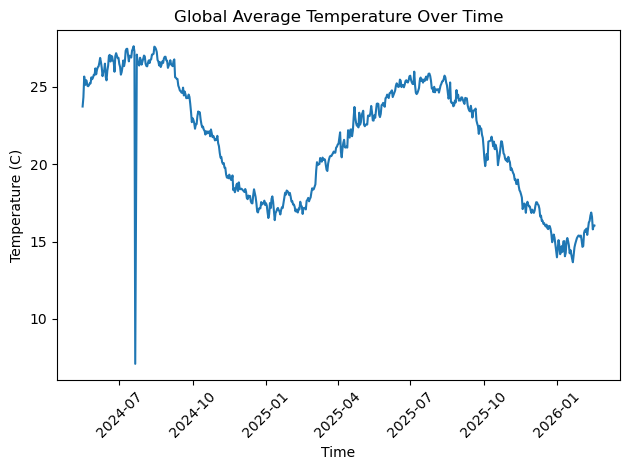

In [106]:
# Global Trend – Average Temperature Over Time

# Convert datetime to date
df_daily = df.copy()
df_daily["date"] = df_daily["last_updated_epoch"].dt.date

# Group by date
global_temp_daily = (df_daily.groupby("date")["temperature_celsius"].mean())

plt.figure()
plt.plot(global_temp_daily.index, global_temp_daily.values)
plt.title("Global Average Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("global_average_temperature_over_time.png")
plt.show()

In [26]:
global_temp_daily[global_temp_daily < 10]

date
2024-07-21    7.1
Name: temperature_celsius, dtype: float64

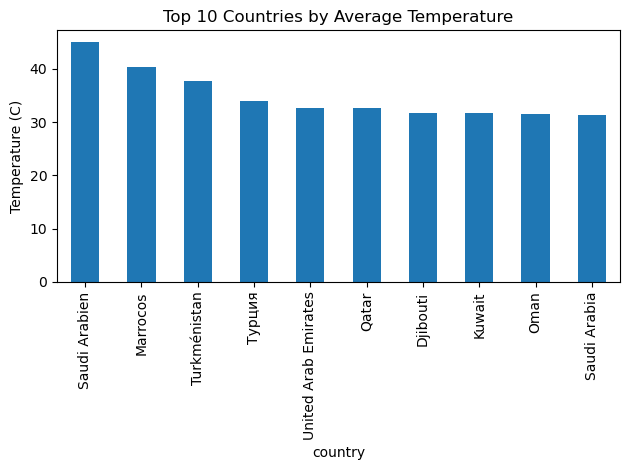

In [97]:
# Per-Country Temperature Comparison

country_temp = (df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False))

# Top 10 countries
plt.figure()
country_temp.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Average Temperature")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("top_countries_temp.png")
plt.show()

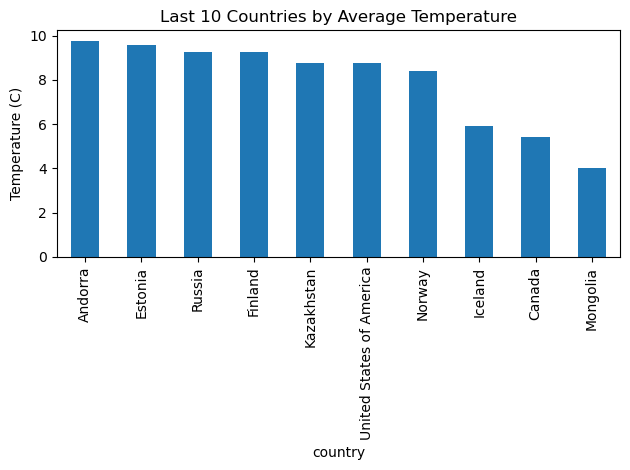

In [98]:
# Last 10 countries

plt.figure()
country_temp.tail(10).plot(kind="bar")
plt.title("Last 10 Countries by Average Temperature")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("last_countries_temp.png")
plt.show()

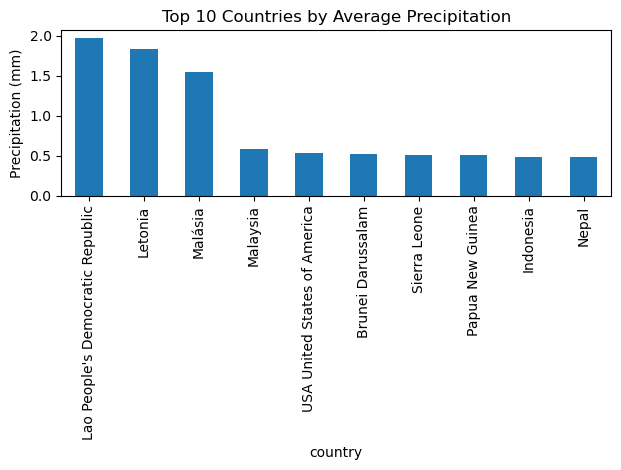

In [95]:
# Per-Country Precipitation Comparison

country_precip = (df.groupby("country")["precip_mm"].mean().sort_values(ascending=False))

# Top 10 countries
plt.figure()
country_precip.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Average Precipitation")
plt.ylabel("Precipitation (mm)")
plt.xticks(rotation=90)
plt.tight_layout()
#plt.savefig("top_countries_preicp.png")
plt.show()

In [99]:
country_precip.tail(10)

country
Libya            0.0
Marrocos         0.0
Polônia          0.0
Mexique          0.0
Saudi Arabien    0.0
Turkménistan     0.0
Гватемала        0.0
Польша           0.0
Турция           0.0
火鸡               0.0
Name: precip_mm, dtype: float64

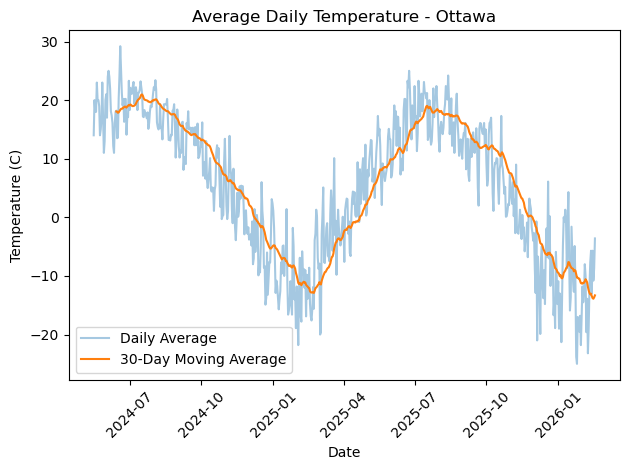

In [83]:
city_df = df_daily[
    (df_daily["country"] == "Canada") &
    (df_daily["location_name"] == "Ottawa")
    ]

city_daily_temp = (city_df.groupby("date")["temperature_celsius"].mean().sort_index())
city_daily_temp_smooth = city_daily_temp.rolling(window=30).mean()

plt.figure()
plt.plot(city_daily_temp.index, city_daily_temp.values, alpha=0.4, label="Daily Average")
plt.plot(city_daily_temp_smooth.index, city_daily_temp_smooth.values, label="30-Day Moving Average")
plt.title("Average Daily Temperature - Ottawa")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
#plt.savefig("average_temperature_over_time_ottawa.png")
plt.show()

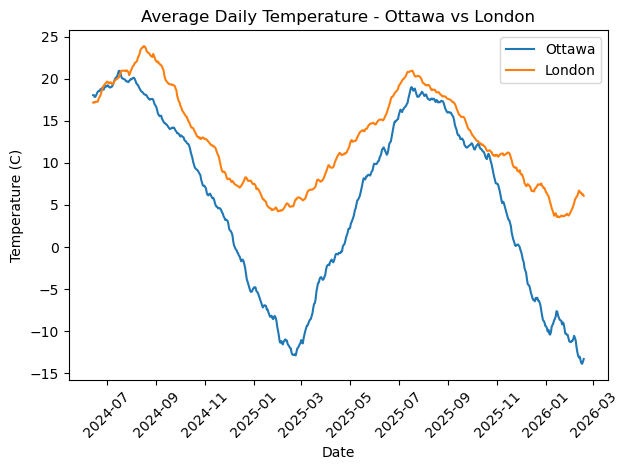

In [84]:
df_city = df_daily.copy()

city2_df = df_city[
    (df_city["country"] == "United Kingdom") &
    (df_city["location_name"] == "London")
    ]

city2_daily_temp = (city2_df.groupby("date")["temperature_celsius"].mean().sort_index())
city2_daily_temp_smooth = city2_daily_temp.rolling(window=30).mean()

plt.figure()
plt.plot(city_daily_temp_smooth.index, city_daily_temp_smooth.values, label="Ottawa")
plt.plot(city2_daily_temp_smooth.index, city2_daily_temp_smooth.values, label="London")
plt.title("Average Daily Temperature - Ottawa vs London")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
#plt.savefig("average_temperature_over_time_ottawa_vs_london.png")
plt.show()

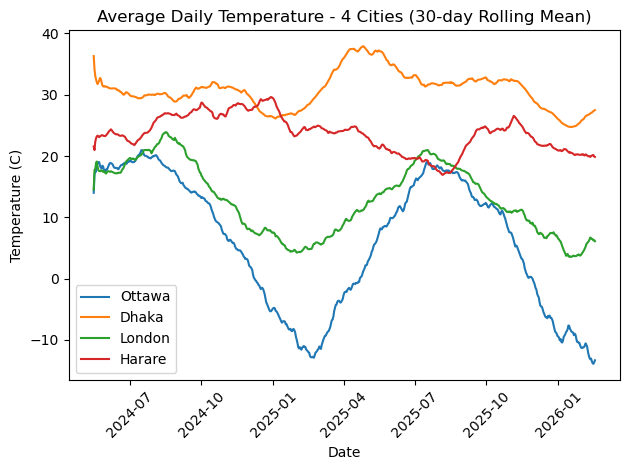

In [80]:
cities = {
    "Ottawa": ("Canada", "Ottawa"),
    "Dhaka": ("Bangladesh", "Dhaka"),
    "London": ("United Kingdom", "London"),
    "Harare": ("Zimbabwe", "Harare"),
}

df_city = df_daily.copy()

plt.figure()

for label, (country, city) in cities.items():
    city_df = df_city[
        (df_city["country"] == country) &
        (df_city["location_name"] == city)
    ]

    city_daily_temp = (
        city_df.groupby("date")["temperature_celsius"]
        .mean()
        .sort_index()
    )

    city_daily_temp_smooth = city_daily_temp.rolling(window=30, min_periods=1).mean()

    plt.plot(city_daily_temp_smooth.index, city_daily_temp_smooth.values, label=label)

plt.title("Average Daily Temperature - 4 Cities (30-day Rolling Mean)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
#plt.savefig("average_temperature_over_time_4_cities.png", dpi=300)
plt.show()

### Precipitation

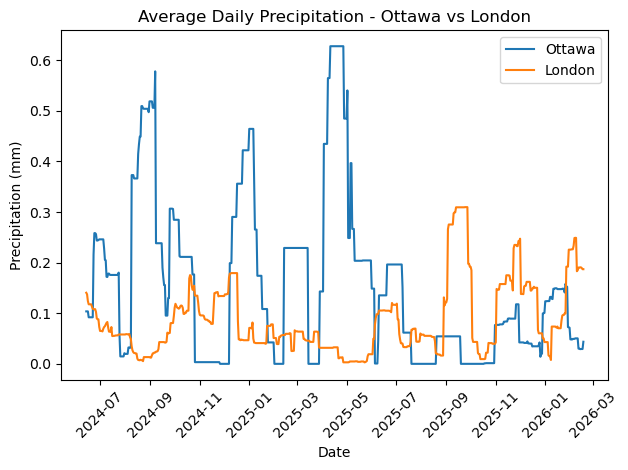

In [85]:
city_daily_precip = (city_df.groupby("date")["precip_mm"].mean().sort_index())
city_daily_precip_smooth = city_daily_precip.rolling(window=30).mean()

city2_daily_precip = (city2_df.groupby("date")["precip_mm"].mean().sort_index())
city2_daily_precip_smooth = city2_daily_precip.rolling(window=30).mean()

plt.figure()
plt.plot(city_daily_precip_smooth.index, city_daily_precip_smooth.values, alpha=1, label="Ottawa")
plt.plot(city2_daily_precip_smooth.index, city2_daily_precip_smooth.values, label="London")
plt.title("Average Daily Precipitation - Ottawa vs London")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("average_precip_over_time_ottawa_vs_london.png")
plt.show()

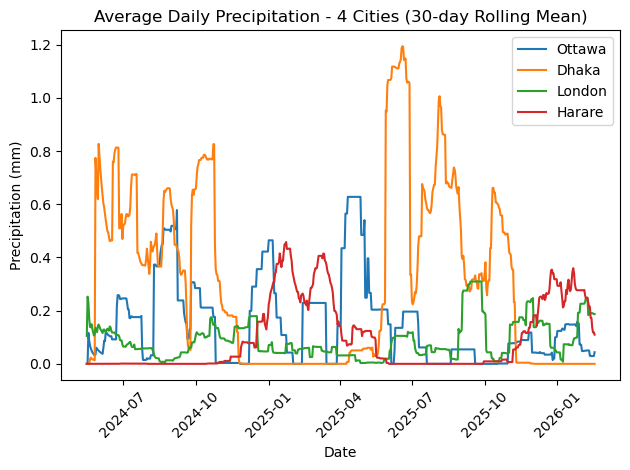

In [79]:
# 4-city precipitation comparison (30-day rolling mean)

cities = {
    "Ottawa": ("Canada", "Ottawa"),
    "Dhaka": ("Bangladesh", "Dhaka"),
    "London": ("United Kingdom", "London"),
    "Harare": ("Zimbabwe", "Harare"),
}

df_city = df_daily.copy()

plt.figure()

for label, (country, city) in cities.items():
    city_df = df_city[
        (df_city["country"] == country) &
        (df_city["location_name"] == city)
    ]

    city_daily_precip = (
        city_df.groupby("date")["precip_mm"]
        .mean()
        .sort_index()
    )

    city_daily_precip_smooth = city_daily_precip.rolling(window=30, min_periods=1).mean()

    plt.plot(
        city_daily_precip_smooth.index,
        city_daily_precip_smooth.values,
        label=label
    )

plt.title("Average Daily Precipitation - 4 Cities (30-day Rolling Mean)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
#plt.savefig("average_daily_precipitation_4_cities.png", dpi=300)
plt.show()

In [50]:
# Numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Exclude similar columns, time columns and co-ordinates from numeric columns
exclude_cols = {
    "last_updated", "last_updated_epoch", "sunrise", "sunset", "moonrise", "moonset",
    "latitude", "longitude", "temperature_fahrenheit", "wind_kph", "pressure_in", "precip_in",
    "feels_like_fahrenheit", "visibility_km", "gust_kph"
}

numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

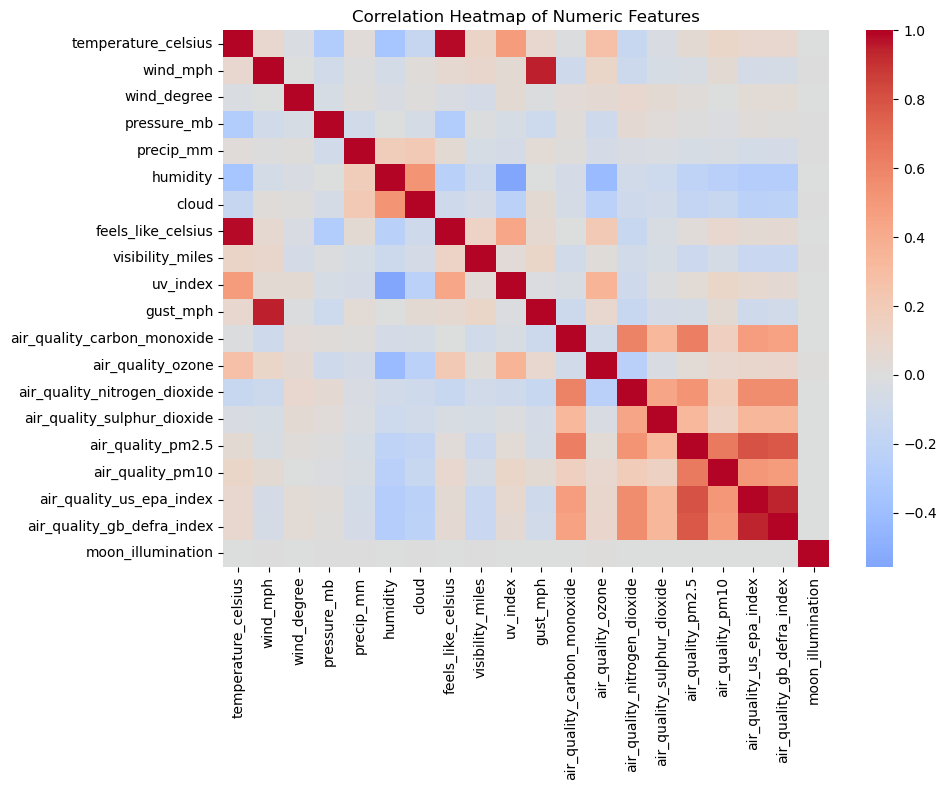

In [114]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
#plt.savefig("heatmap_all.png")
plt.show()

In [111]:
pairs = [
    ("Canada", "Ottawa"),
    ("United Kingdom", "London"),
    ("Zimbabwe", "Harare"),
    ("Bangladesh", "Dhaka"),
    ("Australia", "Canberra"),
]

In [112]:
df_city = df_daily.copy()

# filter the selected (country, city) pairs
pairs_set = set(pairs)
df_city = df_city[df_city.apply(lambda r: (r["country"], r["location_name"]) in pairs_set, axis=1)]

# create a unique label per location
df_city["label"] = df_city["country"] + " - " + df_city["location_name"]

# daily mean temperature per location
daily_temp = (
    df_city.groupby(["date", "label"])["temperature_celsius"]
          .mean()
          .reset_index()
)

# pivot: rows = date, cols = location label
temp_wide = daily_temp.pivot(index="date", columns="label", values="temperature_celsius")

temp_wide.head()

label,Australia - Canberra,Bangladesh - Dhaka,Canada - Ottawa,United Kingdom - London,Zimbabwe - Harare
date,,,,,
2024-05-16,7.0,36.3,14.0,14.5,21.55
2024-05-17,7.0,32.0,20.0,21.0,20.40
2024-05-18,NaN,30.8,18.0,18.0,25.10
2024-05-19,-1.0,30.8,18.0,22.0,24.50
2024-05-20,3.0,30.3,23.0,20.0,24.50


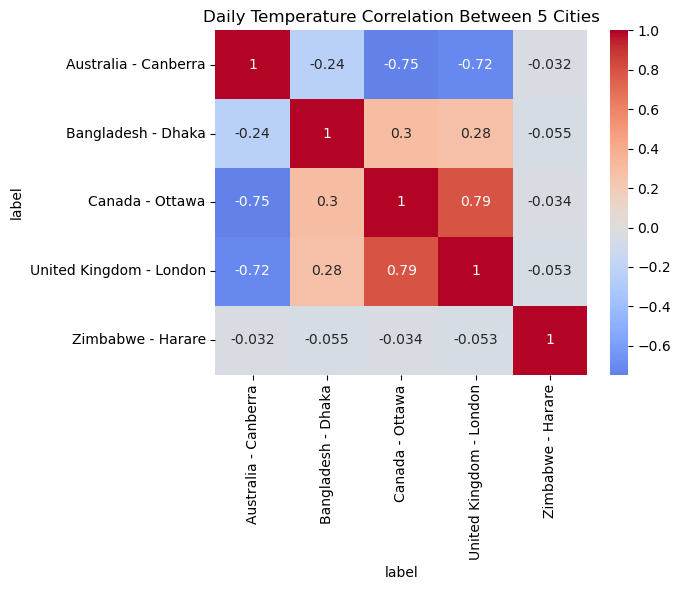

In [115]:
corr_cities = temp_wide.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_cities, annot=True, cmap="coolwarm", center=0)
plt.title("Daily Temperature Correlation Between 5 Cities")
plt.tight_layout()
#plt.savefig("heatmap_temp.png")
plt.show()

In [117]:
df_city = df_daily.copy()

# filter the selected (country, city) pairs
pairs_set = set(pairs)
df_city = df_city[df_city.apply(lambda r: (r["country"], r["location_name"]) in pairs_set, axis=1)]

# create a unique label per location
df_city["label"] = df_city["country"] + " - " + df_city["location_name"]

# daily mean temperature per location
daily_precip = (
    df_city.groupby(["date", "label"])["precip_mm"]
          .mean()
          .reset_index()
)

# pivot: rows = date, cols = location label
precip_wide = daily_precip.pivot(index="date", columns="label", values="precip_mm")

precip_wide.head()

label,Australia - Canberra,Bangladesh - Dhaka,Canada - Ottawa,United Kingdom - London,Zimbabwe - Harare
date,,,,,
2024-05-16,0.00,0.00,0.00,0.105,0.0
2024-05-17,0.22,0.00,0.00,0.400,0.0
2024-05-18,NaN,0.00,0.35,0.190,0.0
2024-05-19,0.00,0.00,0.00,0.000,0.0
2024-05-20,0.00,0.08,0.00,0.000,0.0


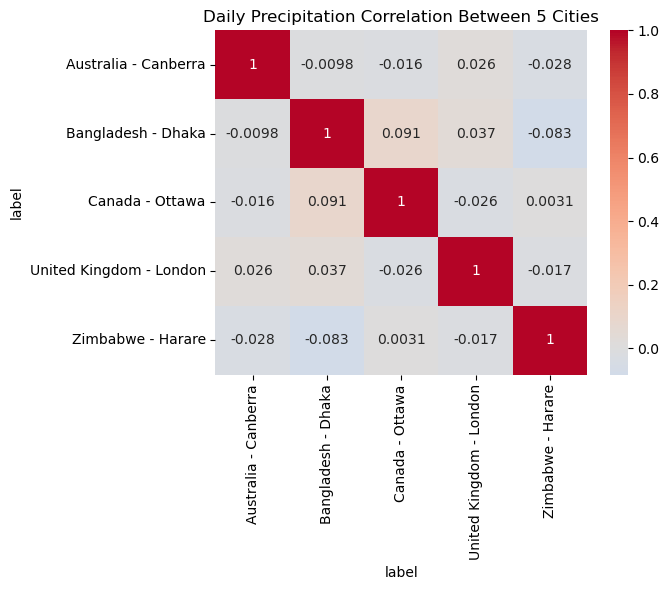

In [119]:
corr_cities = precip_wide.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_cities, annot=True, cmap="coolwarm", center=0)
plt.title("Daily Precipitation Correlation Between 5 Cities")
plt.tight_layout()
#plt.savefig("heatmap_precip.png")
plt.show()